<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Deep-Learning/blob/main/Practicals/DL_Pract_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Reshape image data to 2D format
x_train_reshaped = x_train_normalized.reshape(-1, 28 * 28)
x_test_reshaped = x_test_normalized.reshape(-1, 28 * 28)

# Convert labels to tf.int64
y_train_int64 = tf.cast(y_train, tf.int64)
y_test_int64 = tf.cast(y_test, tf.int64)

print(f"x_train_reshaped shape: {x_train_reshaped.shape}")
print(f"y_train_int64 shape: {y_train_int64.shape}")
print(f"x_test_reshaped shape: {x_test_reshaped.shape}")
print(f"y_test_int64 shape: {y_test_int64.shape}")

x_train_reshaped shape: (60000, 784)
y_train_int64 shape: (60000,)
x_test_reshaped shape: (10000, 784)
y_test_int64 shape: (10000,)


In [ ]:
class SimpleDNN(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        # Input layer: 784 features (28*28 images)
        # Hidden layer: 128 units
        # Output layer: 10 units (10 classes for Fashion MNIST)
        input_size = 784
        hidden_size = 128
        output_size = 10

        # Initialize weights and biases for the hidden layer
        self.w1 = tf.Variable(tf.random.normal([input_size, hidden_size]), name='weights_hidden')
        self.b1 = tf.Variable(tf.zeros([hidden_size]), name='bias_hidden')

        # Initialize weights and biases for the output layer
        self.w2 = tf.Variable(tf.random.normal([hidden_size, output_size]), name='weights_output')
        self.b2 = tf.Variable(tf.zeros([output_size]), name='bias_output')

    def __call__(self, x):
        # Reshape input if it's not already flat (optional, but good for consistency)
        # This assumes x can be reshaped from (batch_size, 28, 28) to (batch_size, 784)
        # However, our preprocessed data x_train_reshaped is already (batch_size, 784)
        # So we might not need this if we always pass reshaped data.
        # For robustness, we can add a check:
        if len(x.shape) > 2:
            x = tf.reshape(x, [-1, 28 * 28])

        # Hidden layer with ReLU activation
        hidden_output = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)

        # Output layer (logits)
        logits = tf.matmul(hidden_output, self.w2) + self.b2
        return logits

# Instantiate the SimpleDNN model
model = SimpleDNN(name='fashion_mnist_dnn')

print("SimpleDNN model instantiated successfully.")
# Print the shapes of the model's variables to verify
print(f"Weights 1 shape: {model.w1.shape}")
print(f"Bias 1 shape: {model.b1.shape}")
print(f"Weights 2 shape: {model.w2.shape}")
print(f"Bias 2 shape: {model.b2.shape}")

SimpleDNN model instantiated successfully.
Weights 1 shape: (784, 128)
Bias 1 shape: (128,)
Weights 2 shape: (128, 10)
Bias 2 shape: (10,)


In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x7ba7f3a0c4a0>, kwargs={'from_logits': True, 'ignore_class': None, 'axis': -1})>
Optimizer: <keras.src.optimizers.sgd.SGD object at 0x7ba7c9c33620>


In [ ]:
train_losses = []
train_accuracies = []

num_epochs = 10
batch_size = 64

# Create a tf.data.Dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_reshaped, y_train_int64))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

print(f"Starting training for {num_epochs} epochs with batch size {batch_size}...")

for epoch in range(num_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            # Forward pass
            logits = model(x_batch)
            # Calculate loss
            loss_value = loss_fn(y_batch, logits)

        # Compute gradients
        grads = tape.gradient(loss_value, model.trainable_variables)

        # Apply gradients to update weights
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # Track progress
        epoch_loss_avg.update_state(loss_value)
        epoch_accuracy_metric.update_state(y_batch, logits)

    # End epoch
    train_losses.append(epoch_loss_avg.result().numpy())
    train_accuracies.append(epoch_accuracy_metric.result().numpy())

    print(f"Epoch {epoch + 1}/{num_epochs}: ",
          f"Loss: {epoch_loss_avg.result():.4f}, ",
          f"Accuracy: {epoch_accuracy_metric.result():.4f}")

print("Training finished.")

Starting training for 10 epochs with batch size 64...
Epoch 1/10:  Loss: 10.3717,  Accuracy: 0.6359
Epoch 2/10:  Loss: 4.0534,  Accuracy: 0.7249
Epoch 3/10:  Loss: 2.6130,  Accuracy: 0.7410
Epoch 4/10:  Loss: 1.9235,  Accuracy: 0.7451
Epoch 5/10:  Loss: 1.5509,  Accuracy: 0.7500
Epoch 6/10:  Loss: 1.3297,  Accuracy: 0.7528
Epoch 7/10:  Loss: 1.1784,  Accuracy: 0.7572
Epoch 8/10:  Loss: 1.0738,  Accuracy: 0.7605
Epoch 9/10:  Loss: 0.9919,  Accuracy: 0.7647
Epoch 10/10:  Loss: 0.9295,  Accuracy: 0.7683
Training finished.


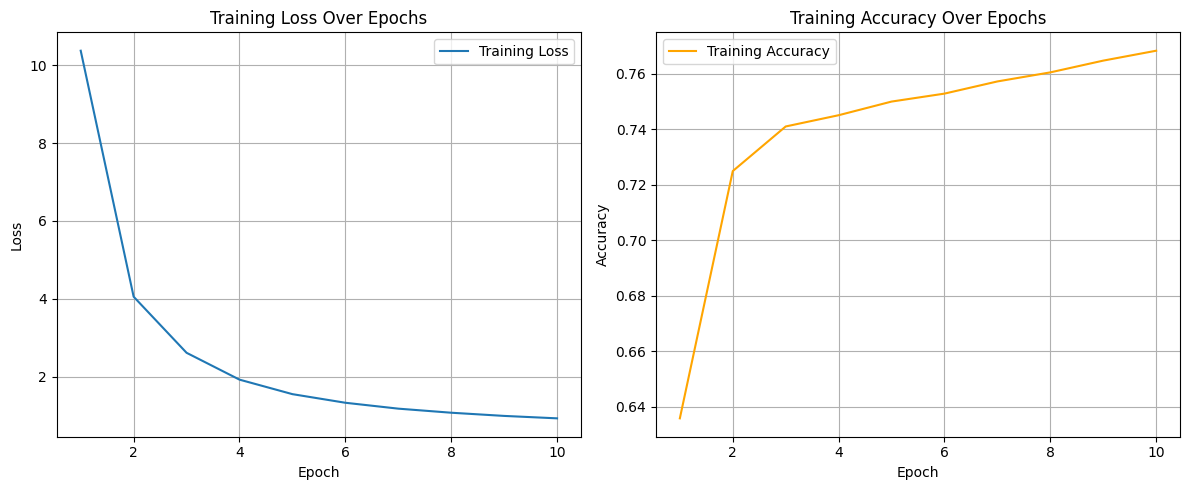

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(np.arange(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)

# Plot training accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(np.arange(1, num_epochs + 1), train_accuracies, label='Training Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(True)

# Ensure proper spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()